# Experiment 4: Term Frequency Analysis and Named Entity Recognition (NER)

This notebook implements all three parts of Experiment 4:

- **4.1** — Term Frequency (TF) and Named Entity Recognition (NER) using an NLP toolkit (**spaCy**)
- **4.2** — Term Frequency (TF) without using any NLP toolkit (pure Python)
- **4.3** — TF-IDF calculation for multiple documents, implemented from scratch (no NLP toolkit)

**Input file used for 4.1 and 4.2:** `4.1_4.2_input.txt`

---
## Common Imports

In [3]:
import string
import math

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option('display.max_colwidth', None)

---
# Part 4.1 — Term Frequency & NER using a Toolkit (spaCy)

Steps performed:
1. Load the input text file
2. Tokenize the text using spaCy and compute the frequency of every word
3. Save the (Term, Frequency) table as a CSV file
4. Display the top 10 most frequent terms
5. Run spaCy's Named Entity Recognizer and display the detected entities

### 4.1.1 Load spaCy and the input text

In [4]:
# Run this once if spaCy / the English model is not already installed:
# !pip install spacy
# !python -m spacy download en_core_web_sm

import spacy

nlp = spacy.load("en_core_web_sm")

with open("4.1_4.2_input.txt", "r", encoding="utf-8") as f:
    text_4_1 = f.read()

print(text_4_1)

Natural Language Processing and Artificial Intelligence

Natural Language Processing, commonly known as NLP, is an important area of artificial intelligence that focuses on enabling computers to understand, process, analyze, and generate human language. Human beings communicate through languages such as English, Hindi, Assamese, Bengali, Tamil, Telugu, Marathi, and many other languages. Computers, however, process information in numerical and symbolic forms. NLP provides methods that help bridge the gap between human communication and computer systems. It combines ideas from computer science, linguistics, statistics, machine learning, and artificial intelligence.

The history of language processing began with rule-based approaches. Early researchers attempted to represent language using manually written grammar rules, dictionaries, and logical structures. These systems could perform specific tasks when the rules were carefully designed, but they often struggled with the complexity and 

### 4.1.2 Term Frequency using spaCy tokenization

In [5]:
doc = nlp(text_4_1)

# Keep only alphabetic tokens (drops punctuation, numbers, whitespace) and normalize case
tokens_4_1 = [token.text.lower() for token in doc if token.is_alpha]

freq_4_1 = {}
for term in tokens_4_1:
    freq_4_1[term] = freq_4_1.get(term, 0) + 1

tf_df_4_1 = pd.DataFrame(freq_4_1.items(), columns=["Term", "Frequency"])
tf_df_4_1 = tf_df_4_1.sort_values(by="Frequency", ascending=False).reset_index(drop=True)

tf_df_4_1.to_csv("4.1_term_frequency.csv", index=False)
tf_df_4_1

,Term,Frequency
0,a,88
1,and,86
2,the,75
3,of,42
4,can,42
...,...,...
738,programs,1
739,prepares,1
740,images,1
741,personal,1


### 4.1.3 Top 10 most frequent terms

In [6]:
top10_4_1 = tf_df_4_1.head(10)
top10_4_1

,Term,Frequency
0,a,88
1,and,86
2,the,75
3,of,42
4,can,42
5,to,42
6,in,42
7,is,37
8,word,30
9,may,30


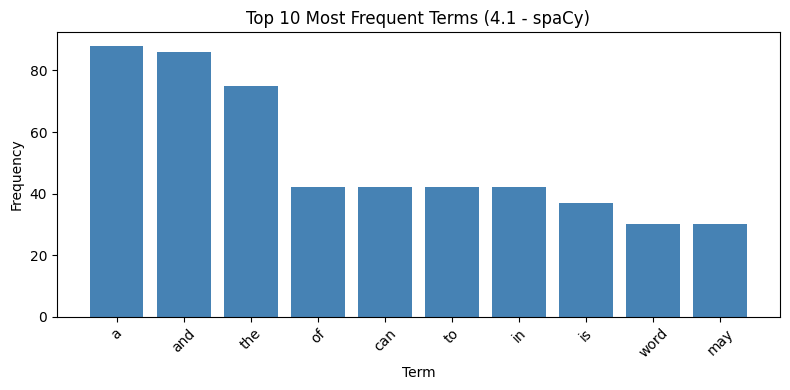

In [7]:
plt.figure(figsize=(8, 4))
plt.bar(top10_4_1["Term"], top10_4_1["Frequency"], color="steelblue")
plt.title("Top 10 Most Frequent Terms (4.1 - spaCy)")
plt.xlabel("Term")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 4.1.4 Named Entity Recognition (NER)

In [8]:
entities_4_1 = [(ent.text, ent.label_) for ent in doc.ents]

ner_df_4_1 = pd.DataFrame(entities_4_1, columns=["Entity", "Label"])
ner_df_4_1.to_csv("4.1_named_entities.csv", index=False)
ner_df_4_1

,Entity,Label
0,Natural Language Processing and Artificial Intelligence\n\nNatural Language Processing,ORG
1,NLP,ORG
2,English,LANGUAGE
3,Hindi,GPE
4,Assamese,NORP
...,...,...
61,NLP,ORG
62,Dataset,ORG
63,NLP,ORG
64,NLP,ORG


---
# Part 4.2 — Term Frequency without any Toolkit

Steps performed (pure Python, no NLP library):
1. Read the same input file
2. Lowercase the text and strip punctuation manually
3. Tokenize by splitting on whitespace
4. Count word frequencies using a plain dictionary
5. Save the (Term, Frequency) table as a CSV file
6. Display the top 10 most frequent terms

### 4.2.1 Read input and preprocess manually

In [9]:
with open("4.1_4.2_input.txt", "r", encoding="utf-8") as f:
    text_4_2 = f.read()

# Manual cleaning: lowercase + remove punctuation (no toolkit used)
cleaned_text = text_4_2.lower()
cleaned_text = cleaned_text.translate(str.maketrans("", "", string.punctuation))

tokens_4_2 = cleaned_text.split()
print(f"Total tokens: {len(tokens_4_2)}")
print(tokens_4_2[:20])

Total tokens: 2419
['natural', 'language', 'processing', 'and', 'artificial', 'intelligence', 'natural', 'language', 'processing', 'commonly', 'known', 'as', 'nlp', 'is', 'an', 'important', 'area', 'of', 'artificial', 'intelligence']


### 4.2.2 Calculate term frequency manually

In [10]:
freq_4_2 = {}
for term in tokens_4_2:
    if term in freq_4_2:
        freq_4_2[term] += 1
    else:
        freq_4_2[term] = 1

tf_df_4_2 = pd.DataFrame(list(freq_4_2.items()), columns=["Term", "Frequency"])
tf_df_4_2 = tf_df_4_2.sort_values(by="Frequency", ascending=False).reset_index(drop=True)

tf_df_4_2.to_csv("4.2_term_frequency.csv", index=False)
tf_df_4_2

,Term,Frequency
0,a,90
1,and,86
2,the,75
3,to,42
4,in,42
...,...,...
745,transparency,1
746,appropriate,1
747,follow,1
748,sensitive,1


### 4.2.3 Top 10 most frequent terms

In [11]:
top10_4_2 = tf_df_4_2.head(10)
top10_4_2

,Term,Frequency
0,a,90
1,and,86
2,the,75
3,to,42
4,in,42
5,can,41
6,of,40
7,is,37
8,word,30
9,may,30


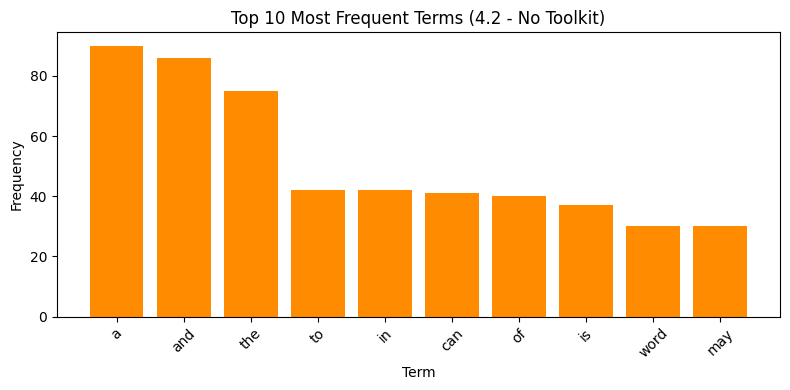

In [12]:
plt.figure(figsize=(8, 4))
plt.bar(top10_4_2["Term"], top10_4_2["Frequency"], color="darkorange")
plt.title("Top 10 Most Frequent Terms (4.2 - No Toolkit)")
plt.xlabel("Term")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

---
# Part 4.3 — TF-IDF from Scratch (No Toolkit)

Documents used:

| Doc | Text |
|-----|------|
| Document 1 | Natural language processing is a field of artificial intelligence. |
| Document 2 | Natural language processing helps computers understand human language. |
| Document 3 | Machine learning is an important part of artificial intelligence. |

Steps performed:
1. Read the documents
2. Lowercase the text
3. Remove punctuation
4. Tokenize
5. Compute TF (Term Frequency) for every term in every document
6. Compute DF (Document Frequency) for every term
7. Compute IDF = log10(N / DF)
8. Compute TF-IDF = TF × IDF
9. Display Term, TF, DF, IDF, TF-IDF at every step
10. Identify top 10 terms with the highest TF-IDF score in each document

### 4.3.1 Read the documents

In [13]:
documents = {
    "Document 1": "Natural language processing is a field of artificial intelligence.",
    "Document 2": "Natural language processing helps computers understand human language.",
    "Document 3": "Machine learning is an important part of artificial intelligence.",
}

for name, content in documents.items():
    print(f"{name}: {content}")

Document 1: Natural language processing is a field of artificial intelligence.
Document 2: Natural language processing helps computers understand human language.
Document 3: Machine learning is an important part of artificial intelligence.


### 4.3.2 Preprocess: lowercase, remove punctuation, tokenize

In [14]:
def preprocess(text):
    text = text.lower()
    text = text.translate(str.maketrans("", "", string.punctuation))
    tokens = text.split()
    return tokens

doc_tokens = {name: preprocess(content) for name, content in documents.items()}

for name, tokens in doc_tokens.items():
    print(f"{name}: {tokens}")

Document 1: ['natural', 'language', 'processing', 'is', 'a', 'field', 'of', 'artificial', 'intelligence']
Document 2: ['natural', 'language', 'processing', 'helps', 'computers', 'understand', 'human', 'language']
Document 3: ['machine', 'learning', 'is', 'an', 'important', 'part', 'of', 'artificial', 'intelligence']


### 4.3.3 Step 5 — Term Frequency (TF) per document

TF(term, doc) = (count of term in doc) / (total terms in doc)

In [15]:
def compute_tf(tokens):
    tf = {}
    total_terms = len(tokens)
    for term in tokens:
        tf[term] = tf.get(term, 0) + 1
    for term in tf:
        tf[term] = tf[term] / total_terms
    return tf

tf_scores = {name: compute_tf(tokens) for name, tokens in doc_tokens.items()}

tf_rows = []
for name, tf in tf_scores.items():
    for term, score in tf.items():
        tf_rows.append({"Document": name, "Term": term, "TF": round(score, 4)})

tf_table = pd.DataFrame(tf_rows).sort_values(["Document", "Term"]).reset_index(drop=True)
tf_table

,Document,Term,TF
0,Document 1,a,0.1111
1,Document 1,artificial,0.1111
2,Document 1,field,0.1111
3,Document 1,intelligence,0.1111
4,Document 1,is,0.1111
5,Document 1,language,0.1111
6,Document 1,natural,0.1111
7,Document 1,of,0.1111
8,Document 1,processing,0.1111
9,Document 2,computers,0.1250


### 4.3.4 Step 6 — Document Frequency (DF)

DF(term) = number of documents in which the term appears

In [16]:
def compute_df(all_doc_tokens):
    df = {}
    for tokens in all_doc_tokens.values():
        for term in set(tokens):
            df[term] = df.get(term, 0) + 1
    return df

df_scores = compute_df(doc_tokens)

df_table = pd.DataFrame(list(df_scores.items()), columns=["Term", "DF"])
df_table = df_table.sort_values("Term").reset_index(drop=True)
df_table

,Term,DF
0,a,1
1,an,1
2,artificial,2
3,computers,1
4,field,1
5,helps,1
6,human,1
7,important,1
8,intelligence,2
9,is,2


### 4.3.5 Step 7 — Inverse Document Frequency (IDF)

IDF(term) = log10(N / DF(term))  where N = total number of documents

In [17]:
N = len(documents)

idf_scores = {term: math.log10(N / df) for term, df in df_scores.items()}

idf_table = pd.DataFrame(list(idf_scores.items()), columns=["Term", "IDF"])
idf_table["IDF"] = idf_table["IDF"].round(4)
idf_table = idf_table.sort_values("Term").reset_index(drop=True)
idf_table

,Term,IDF
0,a,0.4771
1,an,0.4771
2,artificial,0.1761
3,computers,0.4771
4,field,0.4771
5,helps,0.4771
6,human,0.4771
7,important,0.4771
8,intelligence,0.1761
9,is,0.1761


### 4.3.6 Step 8 & 9 — TF-IDF and full summary table

TF-IDF(term, doc) = TF(term, doc) × IDF(term)

In [18]:
summary_rows = []
for name, tf in tf_scores.items():
    for term, tf_value in tf.items():
        df_value = df_scores[term]
        idf_value = idf_scores[term]
        tfidf_value = tf_value * idf_value
        summary_rows.append({
            "Document": name,
            "Term": term,
            "TF": round(tf_value, 4),
            "DF": df_value,
            "IDF": round(idf_value, 4),
            "TF-IDF": round(tfidf_value, 4),
        })

tfidf_table = pd.DataFrame(summary_rows)
tfidf_table = tfidf_table.sort_values(["Document", "TF-IDF"], ascending=[True, False]).reset_index(drop=True)

tfidf_table.to_csv("4.3_tfidf_scores.csv", index=False)
tfidf_table

,Document,Term,TF,DF,IDF,TF-IDF
0,Document 1,a,0.1111,1,0.4771,0.0530
1,Document 1,field,0.1111,1,0.4771,0.0530
2,Document 1,natural,0.1111,2,0.1761,0.0196
3,Document 1,language,0.1111,2,0.1761,0.0196
4,Document 1,processing,0.1111,2,0.1761,0.0196
5,Document 1,is,0.1111,2,0.1761,0.0196
6,Document 1,of,0.1111,2,0.1761,0.0196
7,Document 1,artificial,0.1111,2,0.1761,0.0196
8,Document 1,intelligence,0.1111,2,0.1761,0.0196
9,Document 2,helps,0.1250,1,0.4771,0.0596


### 4.3.7 Step 10 — Top 10 terms by TF-IDF, per document

In [19]:
for name in documents:
    print(f"\nTop terms for {name}:")
    doc_top = (
        tfidf_table[tfidf_table["Document"] == name]
        .sort_values("TF-IDF", ascending=False)
        .head(10)
        .reset_index(drop=True)
    )
    display(doc_top)


Top terms for Document 1:


,Document,Term,TF,DF,IDF,TF-IDF
0,Document 1,a,0.1111,1,0.4771,0.0530
1,Document 1,field,0.1111,1,0.4771,0.0530
2,Document 1,natural,0.1111,2,0.1761,0.0196
3,Document 1,language,0.1111,2,0.1761,0.0196
4,Document 1,processing,0.1111,2,0.1761,0.0196
5,Document 1,is,0.1111,2,0.1761,0.0196
6,Document 1,of,0.1111,2,0.1761,0.0196
7,Document 1,artificial,0.1111,2,0.1761,0.0196
8,Document 1,intelligence,0.1111,2,0.1761,0.0196



Top terms for Document 2:


,Document,Term,TF,DF,IDF,TF-IDF
0,Document 2,helps,0.125,1,0.4771,0.0596
1,Document 2,computers,0.125,1,0.4771,0.0596
2,Document 2,understand,0.125,1,0.4771,0.0596
3,Document 2,human,0.125,1,0.4771,0.0596
4,Document 2,language,0.250,2,0.1761,0.0440
5,Document 2,natural,0.125,2,0.1761,0.0220
6,Document 2,processing,0.125,2,0.1761,0.0220



Top terms for Document 3:


,Document,Term,TF,DF,IDF,TF-IDF
0,Document 3,machine,0.1111,1,0.4771,0.0530
1,Document 3,learning,0.1111,1,0.4771,0.0530
2,Document 3,an,0.1111,1,0.4771,0.0530
3,Document 3,important,0.1111,1,0.4771,0.0530
4,Document 3,part,0.1111,1,0.4771,0.0530
5,Document 3,is,0.1111,2,0.1761,0.0196
6,Document 3,of,0.1111,2,0.1761,0.0196
7,Document 3,artificial,0.1111,2,0.1761,0.0196
8,Document 3,intelligence,0.1111,2,0.1761,0.0196


---
## Output Files Generated

| File | Description |
|------|--------------|
| `4.1_term_frequency.csv` | Term, Frequency table from Part 4.1 (spaCy) |
| `4.1_named_entities.csv` | Entity, Label table from Part 4.1 NER |
| `4.2_term_frequency.csv` | Term, Frequency table from Part 4.2 (no toolkit) |
| `4.3_tfidf_scores.csv` | Document, Term, TF, DF, IDF, TF-IDF table from Part 4.3 |